In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 74.4 MB/s eta 0:00:00


In [2]:
import torch
import pennylane as qml
import matplotlib.pyplot as plt
from pennylane import numpy as np
from pennylane.optimize import NesterovMomentumOptimizer
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

In [3]:
seed = 42
np.random.seed(seed)

### Parameters

In [4]:
num_qubits = 9
num_layers = 10
num_params = num_layers * num_qubits * 3

num_epochs = 30
num_samples = 500
batch_size = 50
learning_rate = 0.05

### Circuit

In [5]:
dev = qml.device('default.qubit', wires = num_qubits)

@qml.qnode(dev)
def classifier_circuit(weights, x_input, num_qubits, num_layers):
    for i in range(num_layers):
        max_CX = num_qubits - 2 + (i + 2)%2
        min_CX = 1 + (i + 1)%2

        for j in range(num_qubits):
            # encode features
            qml.RX(x_input[i][j][0], wires = j)
            qml.RY(x_input[i][j][1], wires = j)
            qml.RZ(x_input[i][j][2], wires = j)

            # trained parameters
            qml.RX(weights[i][j][0], wires = j)
            qml.RY(weights[i][j][1], wires = j)
            qml.RZ(weights[i][j][2], wires = j)

            if min_CX-1 <= j <= max_CX-1 and (j-min_CX+1)%2 == 0:
                qml.CNOT(wires = [j, j+1])

            if i == num_layers - 1 and j < num_qubits - 1:
                qml.CNOT(wires=[j, j+1])

    return qml.expval(qml.PauliZ(0))

def prediction(weights, bias, x_input, num_qubits, num_layers):
    predictions = [classifier_circuit(weights, x_input[i], num_qubits, num_layers) + bias for i in range(len(x_input))]
    return predictions

def loss(weights, bias, x_input, y, num_qubits, num_layers):
    preds = prediction(weights, bias, x_input, num_qubits, num_layers)

    mse = np.mean((np.array(preds) - y)**2)

    return mse

def acc(labels, predictions):
    predictions = np.sign(predictions)
    acc = sum(abs(l-p) < 1e-2 for l,p in zip(labels, predictions))/len(labels)
    return acc

### Pre-process Data

In [6]:
def data_produce(features, labels, num_layers, num_qubits, num_params, status):
    B, C, H, W = features.shape
    if status == 'train':
        features = features.numpy()

    features = features.reshape(B, -1)
    num_padding = num_params - C*H*W
    features = np.pad(features, ((0, 0), (0, num_padding)), mode='constant', constant_values=0).reshape(B, num_layers, num_qubits, 3)

    labels_conv = np.array([1 if l == 1 else -1 for l in labels], dtype=np.float32)
    return features, labels_conv

In [7]:
trans = transforms.Compose([
    transforms.Resize((16,16)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_mnist = datasets.EMNIST(root='./data', split="mnist", train=True, download=True, transform=trans)
test_mnist = datasets.EMNIST(root='./data', split="mnist", train=False, download=True, transform=trans)

train_indices_19 = [i for i in range(len(train_mnist)) if train_mnist.targets[i] in [1, 9]]
test_indices_19 = [i for i in range(len(test_mnist)) if test_mnist.targets[i] in [1, 9]]

test_indices = np.random.choice(test_indices_19, size=num_samples, replace=False)

test_images = np.stack([test_mnist[i][0].numpy() for i in test_indices])
test_labels = np.array([test_mnist[i][1] for i in test_indices])

100%|██████████| 562M/562M [00:13<00:00, 40.2MB/s]


### Training

NesterovMomentumOptimizer 0.8820

In [8]:
weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3, requires_grad = True)
bias_init = np.array(0.0, requires_grad=True)

opt = NesterovMomentumOptimizer(stepsize=learning_rate)

weights = weights_init
bias = bias_init

train_loss = []
test_acc = []
weights_check = [0,0]
for epoch in range(num_epochs):
    # test
    X_input_test, y_test = data_produce(test_images, test_labels, num_layers, num_qubits, num_params, status='test')
    prediction_test = prediction(weights, bias, X_input_test, num_qubits, num_layers)
    test_acc.append(acc(y_test, prediction_test))

    # train
    train_indices = np.random.choice(train_indices_19, size=num_samples, replace=False)

    train = Subset(train_mnist, train_indices)

    train_loader = DataLoader(train, batch_size=batch_size, shuffle=False, drop_last=False)

    weights_check[0] = weights
    train_loss_epoch = 0
    for X_input, y in train_loader:
        X_input, y = data_produce(X_input, y, num_layers, num_qubits, num_params, status='train')
        weights, bias, _, _, _, _ = opt.step(loss, weights, bias, X_input, y, num_qubits, num_layers)
        train_loss_epoch += loss(weights, bias, X_input, y, num_qubits, num_layers)
    weights_check[1] = weights
    train_loss.append(train_loss_epoch/len(train_loader))

    print(f"Test: Iterations {epoch}, Accuracy {test_acc[-1]:.4f} | Train: Iterations {epoch+1}, Loss {train_loss[-1]:.4f}")
    # print(epoch+1, qml.math.linalg.norm(weights_check[0]-weights_check[1])) #check gradients

Test: Iterations 0, Accuracy 0.5180 | Train: Iterations 1, Loss 0.9741
Test: Iterations 1, Accuracy 0.6000 | Train: Iterations 2, Loss 0.9185
Test: Iterations 2, Accuracy 0.7800 | Train: Iterations 3, Loss 0.7728
Test: Iterations 3, Accuracy 0.8500 | Train: Iterations 4, Loss 0.6532
Test: Iterations 4, Accuracy 0.8960 | Train: Iterations 5, Loss 0.6158
Test: Iterations 5, Accuracy 0.9140 | Train: Iterations 6, Loss 0.5939
Test: Iterations 6, Accuracy 0.9140 | Train: Iterations 7, Loss 0.5832
Test: Iterations 7, Accuracy 0.9120 | Train: Iterations 8, Loss 0.5768
Test: Iterations 8, Accuracy 0.9320 | Train: Iterations 9, Loss 0.5476
Test: Iterations 9, Accuracy 0.9320 | Train: Iterations 10, Loss 0.5216
Test: Iterations 10, Accuracy 0.9300 | Train: Iterations 11, Loss 0.5551
Test: Iterations 11, Accuracy 0.9220 | Train: Iterations 12, Loss 0.5084
Test: Iterations 12, Accuracy 0.9340 | Train: Iterations 13, Loss 0.4914
Test: Iterations 13, Accuracy 0.9320 | Train: Iterations 14, Loss 0.52

### Plot

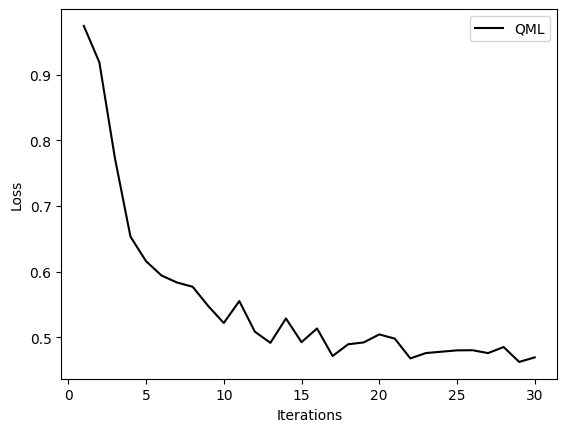

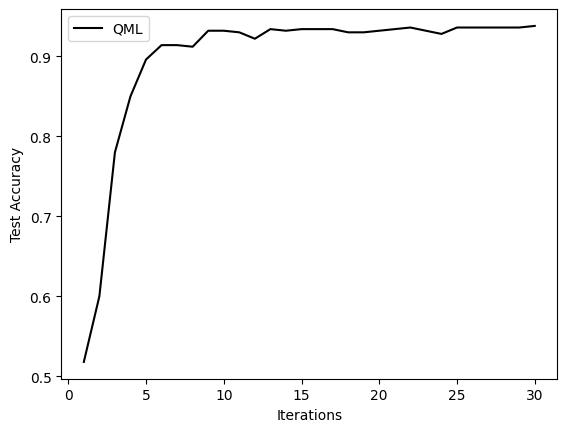

In [9]:
plt.figure()
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.plot(range(1, len(test_acc)+1), train_loss, color = 'black', label = 'QML')
plt.legend()
plt.show()

plt.figure()
plt.xlabel("Iterations")
plt.ylabel("Test Accuracy")
plt.plot(range(1, len(test_acc)+1), test_acc, color = 'black', label = 'QML')
plt.legend()
plt.show()